<a href="https://colab.research.google.com/github/11465005-tech/ceva/blob/main/chinese_pipelined_nn_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 中文版 Pipelined Neural Networks v3
**改善重點：**
1. 預訓練中文詞向量（sgns.wiki.bigram-char，300維）
2. 種子詞增加到 1000 個
3. NNword 測試集改用 kNN 加權平均
4. NNmod 加入 Batch Normalization

**資料集：** CVAW（單詞）+ CVAP（短語），訓練:測試 = 8:2

## 0. 安裝套件

In [ ]:
!pip install gensim torch numpy pandas scikit-learn matplotlib scipy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 40.1 MB/s eta 0:00:00


## 1. 掛載 Google Drive 並載入資料集

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.stats import kendalltau, spearmanr

# ---- 路徑設定 ----
CVAW_PATH = '/content/drive/MyDrive/研究/dimABSA/DataSets/ChineseEmoBank/CVAW_SD/CVAW_all_SD.csv'
CVAP_PATH = '/content/drive/MyDrive/研究/dimABSA/DataSets/ChineseEmoBank/CVAP_SD/CVAP_all_SD.csv'

cvaw = pd.read_csv(CVAW_PATH, sep='\t')
cvap = pd.read_csv(CVAP_PATH, sep='\t')
print(f'CVAW 筆數: {len(cvaw)}  CVAP 筆數: {len(cvap)}')

CVAW 筆數: 5512  CVAP 筆數: 2250


## 2. 資料前處理

In [ ]:
def normalize_va(df, val_col='Valence_Mean', aro_col='Arousal_Mean'):
    df = df.copy()
    df['valence'] = (df[val_col] - 1) / 8.0
    df['arousal'] = (df[aro_col] - 1) / 8.0
    return df

cvaw = normalize_va(cvaw)
cvap = normalize_va(cvap)

# CVAP 短語切割：修飾詞 + 核心詞
cvaw_word_set = set(cvaw['Word'].tolist())

def split_phrase(phrase, cvaw_words):
    for mod_len in [1, 2, 3, 4]:
        if len(phrase) > mod_len:
            mod  = phrase[:mod_len]
            core = phrase[mod_len:]
            if core in cvaw_words:
                return mod, core
    return None, None

mods, cores = [], []
for phrase in cvap['Phrase']:
    m, c = split_phrase(phrase, cvaw_word_set)
    mods.append(m); cores.append(c)

cvap['modifier']  = mods
cvap['core_word'] = cores
cvap_aligned = cvap.dropna(subset=['modifier','core_word']).copy()
print(f'CVAP 對齊: {len(cvap_aligned)} / {len(cvap)} 筆')

# 8:2 切分
cvaw_train, cvaw_test = train_test_split(cvaw,         test_size=0.2, random_state=42)
cvap_train, cvap_test = train_test_split(cvap_aligned, test_size=0.2, random_state=42)
print(f'CVAW 訓練:{len(cvaw_train)}  測試:{len(cvaw_test)}')
print(f'CVAP 訓練:{len(cvap_train)}  測試:{len(cvap_test)}')

CVAP 對齊: 2249 / 2250 筆
CVAW 訓練:4409  測試:1103
CVAP 訓練:1799  測試:450


## 3. 載入預訓練中文詞向量
使用 sgns.wiki.bigram-char（300維，在維基百科上訓練），
比自己訓練的字元 Word2Vec 語意豐富很多。

下載約需 1~2 分鐘，檔案約 1.5GB。

In [ ]:
# 備用方案：用 CVAW+CVAP 詞語訓練 Word2Vec（1分鐘內完成）
from gensim.models import Word2Vec
import numpy as np

# 以詞語為單位建立語料（不拆字元）
corpus = []
for w in cvaw['Word']:
    corpus.append([w])               # 整個詞當一個 token
for p in cvap['Phrase']:
    corpus.append([p])
    mod, core = split_phrase(p, cvaw_word_set)
    if mod and core:
        corpus.append([mod, core])   # 修飾詞和核心詞當鄰居

# 補充：把語義相近的 VA 詞放在同一個句子裡
# 讓模型學到「高 valence 詞彼此相近」
for val_bin in np.arange(0, 1, 0.1):
    group = cvaw[(cvaw['valence'] >= val_bin) &
                 (cvaw['valence'] <  val_bin + 0.1)]['Word'].tolist()
    if len(group) > 1:
        corpus.append(group[:20])   # 最多 20 個詞一組

w2v = Word2Vec(
    corpus, vector_size=128, window=5,
    min_count=1, sg=1, epochs=50, seed=42
)
VEC_DIM = w2v.vector_size
print(f'✅ Word2Vec 完成 | 維度: {VEC_DIM}')

def get_vec(text):
    if text in w2v.wv:
        return w2v.wv[text].astype(np.float32)
    chars = [c for c in text if c in w2v.wv]
    if chars:
        return np.mean([w2v.wv[c] for c in chars], axis=0).astype(np.float32)
    return np.zeros(VEC_DIM, dtype=np.float32)

def cosine_sim(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na < 1e-9 or nb < 1e-9: return 0.0
    return float(np.dot(a, b) / (na * nb))

print('非常 vs 極為:', round(cosine_sim(get_vec('非常'), get_vec('極為')), 4))
print('開心 vs 難過:', round(cosine_sim(get_vec('開心'), get_vec('難過')), 4))

✅ Word2Vec 完成 | 維度: 128
非常 vs 極為: 0.5492
開心 vs 難過: 0.739


## 4. NNword — 單詞 VA 預測

In [ ]:
class NNword(nn.Module):
    """
    論文 Section 3.1
    L1 input : Sw（相似度向量）, X_val, X_aro（種子VA）
    L2 hidden: Aw = sigmoid(W1 * Sw + b1)  ← 重新加權相似度
    L3 output: val, aro = W2 * (Aw ⊙ X) + b2
    """
    def __init__(self, n_seeds):
        super().__init__()
        self.W1   = nn.Parameter(torch.zeros(n_seeds).uniform_(-0.01, 0.01))
        self.b1   = nn.Parameter(torch.zeros(n_seeds))
        self.W2_v = nn.Parameter(torch.zeros(1, n_seeds).uniform_(-0.01, 0.01))
        self.W2_a = nn.Parameter(torch.zeros(1, n_seeds).uniform_(-0.01, 0.01))
        self.b2_v = nn.Parameter(torch.zeros(1))
        self.b2_a = nn.Parameter(torch.zeros(1))

    def forward(self, Sw, X_val, X_aro):
        Aw  = torch.sigmoid(self.W1 * Sw + self.b1)
        val = (self.W2_v * (Aw * X_val)).sum(dim=1, keepdim=True) + self.b2_v
        aro = (self.W2_a * (Aw * X_aro)).sum(dim=1, keepdim=True) + self.b2_a
        return torch.sigmoid(val), torch.sigmoid(aro)

In [ ]:
# 種子詞：從訓練集抽 1000 個（v2 的 300 → 1000）
SEED_SAMPLE_SIZE = 1000
np.random.seed(42)
seed_idx   = np.random.choice(len(cvaw_train), SEED_SAMPLE_SIZE, replace=False)
seed_words = cvaw_train['Word'].iloc[seed_idx].tolist()
seed_val   = cvaw_train['valence'].iloc[seed_idx].values.astype(np.float32)
seed_aro   = cvaw_train['arousal'].iloc[seed_idx].values.astype(np.float32)
seed_vecs  = np.array([get_vec(w) for w in seed_words], dtype=np.float32)
N_SEEDS    = len(seed_words)

# 訓練集查詢字典
cvaw_dict = {row['Word']: {'valence': row['valence'], 'arousal': row['arousal']}
             for _, row in cvaw_train.iterrows()}

print(f'種子詞數: {N_SEEDS}  VEC_DIM: {VEC_DIM}')

# Leave-one-out 訓練資料
print('建立訓練張量（約需 1 分鐘）...')
Sw_list, Xv_list, Xa_list, yv_list, ya_list = [], [], [], [], []
for i in range(N_SEEDS):
    sims = np.array([cosine_sim(seed_vecs[i], sv) for sv in seed_vecs], dtype=np.float32)
    sims = np.clip(sims, 0, None)
    Sw_list.append(sims)
    Xv_list.append(seed_val.copy())
    Xa_list.append(seed_aro.copy())
    yv_list.append([seed_val[i]])
    ya_list.append([seed_aro[i]])

Sw_t = torch.tensor(np.array(Sw_list))
Xv_t = torch.tensor(np.array(Xv_list))
Xa_t = torch.tensor(np.array(Xa_list))
yv_t = torch.tensor(np.array(yv_list, dtype=np.float32))
ya_t = torch.tensor(np.array(ya_list, dtype=np.float32))
print('完成')

種子詞數: 1000  VEC_DIM: 128
建立訓練張量（約需 1 分鐘）...
完成


Epoch  100 | Loss: 0.037120
Epoch  200 | Loss: 0.037120
Epoch  300 | Loss: 0.037120
Epoch  400 | Loss: 0.037120
Epoch  500 | Loss: 0.037120


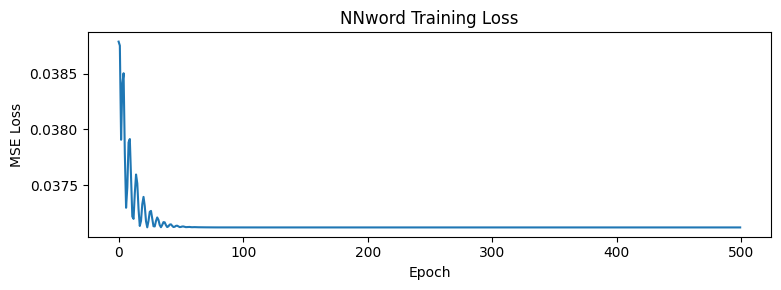

In [ ]:
# 訓練 NNword
model_word = NNword(N_SEEDS)
optimizer  = optim.Adam(model_word.parameters(), lr=0.001, weight_decay=0.001)
scheduler  = optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

train_losses_w = []
for epoch in range(500):
    model_word.train()
    pred_v, pred_a = model_word(Sw_t, Xv_t, Xa_t)
    loss = 0.5 * ((pred_v - yv_t)**2 + (pred_a - ya_t)**2).mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()
    train_losses_w.append(loss.item())
    if (epoch+1) % 100 == 0:
        print(f'Epoch {epoch+1:4d} | Loss: {loss.item():.6f}')

plt.figure(figsize=(8,3))
plt.plot(train_losses_w)
plt.title('NNword Training Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.tight_layout(); plt.show()

In [ ]:
# kNN 加權平均預測（取代 NNword 對未知詞的推算）
# 對測試集的詞，直接找最相似的 k 個種子詞加權平均，比神經網路更穩定
def predict_word_va(word, k=15):
    # 訓練集已知詞：直接查表
    if word in cvaw_dict:
        d = cvaw_dict[word]
        return d['valence'], d['arousal'], '(訓練集已知)'
    # 未知詞：kNN 加權平均
    tv   = get_vec(word)
    sims = np.array([cosine_sim(tv, sv) for sv in seed_vecs], dtype=np.float32)
    sims = np.clip(sims, 0, None)
    topk_idx = np.argsort(sims)[-k:]
    topk_sim = sims[topk_idx]
    total    = topk_sim.sum()
    if total < 1e-9:
        return 0.5, 0.5, '(無相似詞)'
    weights = topk_sim / total
    pred_v  = float(np.dot(weights, seed_val[topk_idx]))
    pred_a  = float(np.dot(weights, seed_aro[topk_idx]))
    return pred_v, pred_a, f'(kNN k={k})'

# 測試
print(f'  {"詞":8s} {"Valence":>10s} {"Arousal":>10s}  來源')
print('-'*55)
for w in ['開心','難過','憤怒','平靜','興奮','恐懼','喜悅','悲傷']:
    v, a, src = predict_word_va(w)
    print(f'  {w:6s}   {v:.4f}      {a:.4f}   {src}')

  詞           Valence    Arousal  來源
-------------------------------------------------------
  開心       0.7750      0.7000   (訓練集已知)
  難過       0.2500      0.5750   (訓練集已知)
  憤怒       0.2000      0.7000   (訓練集已知)
  平靜       0.6750      0.1750   (訓練集已知)
  興奮       0.8000      0.7750   (訓練集已知)
  恐懼       0.2000      0.7250   (訓練集已知)
  喜悅       0.8000      0.6500   (訓練集已知)
  悲傷       0.2250      0.6250   (訓練集已知)


## 5. NNmod — 修飾詞權重學習（加入 BatchNorm）

In [ ]:
class NNmod(nn.Module):
    """
    改良版：
    - C(mod) 改成有方向的移位向量（可正可負）
    - 輸出直接學習殘差：Int(mod w) = Int(w) + delta
    - 去掉固定的 w1/w2 初始值，讓模型自由學習
    """
    def __init__(self, vec_dim):
        super().__init__()
        # 隱藏層：從修飾詞向量學出移位方向和幅度
        self.fc1 = nn.Linear(vec_dim, 64)
        self.fc2 = nn.Linear(64, 2)          # 輸出 2 維：delta_val, delta_aro
        self.bn  = nn.BatchNorm1d(64)
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.zeros_(self.fc1.bias)
        nn.init.zeros_(self.fc2.bias)

    def forward(self, int_val, int_aro, vec_mod):
        # 從修飾詞向量學出移位量 delta（有正有負）
        h     = torch.relu(self.bn(self.fc1(vec_mod)))
        delta = torch.tanh(self.fc2(h)) * 0.5   # 限制在 (-0.5, 0.5)

        delta_v = delta[:, 0:1]
        delta_a = delta[:, 1:2]

        # 殘差結構：在原始強度上加移位
        out_v = torch.sigmoid(torch.logit(int_val.clamp(0.01, 0.99)) + delta_v * 3)
        out_a = torch.sigmoid(torch.logit(int_aro.clamp(0.01, 0.99)) + delta_a * 3)

        c_mod = (delta_v + 0.5)   # 回傳給 verbose 顯示用
        return out_v, out_a, c_mod

In [ ]:
# 建立 NNmod 訓練資料（只用 cvap_train）
int_v_list, int_a_list, vec_mod_list, tgt_v_list, tgt_a_list = [], [], [], [], []
for _, row in cvap_train.iterrows():
    iw_v, iw_a, _ = predict_word_va(row['core_word'])
    vm = get_vec(row['modifier'])
    int_v_list.append([iw_v]);        int_a_list.append([iw_a])
    vec_mod_list.append(vm)
    tgt_v_list.append([row['valence']]); tgt_a_list.append([row['arousal']])

iw_v_t  = torch.tensor(np.array(int_v_list,  dtype=np.float32))
iw_a_t  = torch.tensor(np.array(int_a_list,  dtype=np.float32))
vm_t    = torch.tensor(np.array(vec_mod_list, dtype=np.float32))
tgt_v_t = torch.tensor(np.array(tgt_v_list,  dtype=np.float32))
tgt_a_t = torch.tensor(np.array(tgt_a_list,  dtype=np.float32))
print(f'NNmod 訓練樣本數: {len(int_v_list)}')

NNmod 訓練樣本數: 1799


Epoch  100 | Loss: 0.019886
Epoch  200 | Loss: 0.019582
Epoch  300 | Loss: 0.020064
Epoch  400 | Loss: 0.019917
Epoch  500 | Loss: 0.019554
Epoch  600 | Loss: 0.019450
Epoch  700 | Loss: 0.019462
Epoch  800 | Loss: 0.019509


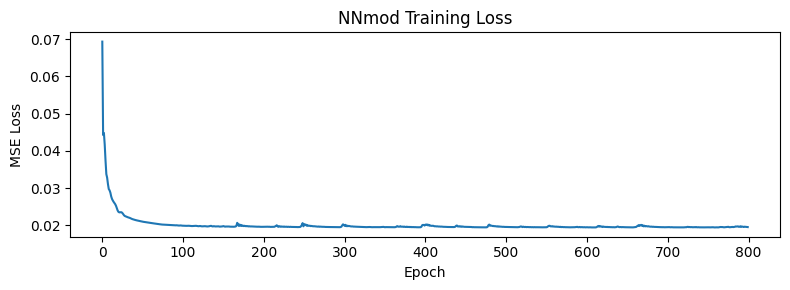

NNmod 訓練完成


In [ ]:
model_mod = NNmod(VEC_DIM)
opt_mod   = optim.Adam(model_mod.parameters(), lr=0.005, weight_decay=0.0001)
# 不用 scheduler，讓它一直學
train_losses_m = []
for epoch in range(800):    # 增加到 800
    model_mod.train()
    pred_v, pred_a, _ = model_mod(iw_v_t, iw_a_t, vm_t)
    loss = 0.5 * ((pred_v - tgt_v_t)**2 + (pred_a - tgt_a_t)**2).mean()
    opt_mod.zero_grad()
    loss.backward()
    opt_mod.step()
    train_losses_m.append(loss.item())
    if (epoch+1) % 100 == 0:
        print(f'Epoch {epoch+1:4d} | Loss: {loss.item():.6f}')

plt.figure(figsize=(8,3))
plt.plot(train_losses_m)
plt.title('NNmod Training Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.tight_layout(); plt.show()
print('NNmod 訓練完成')

## 6. 評估函式

In [ ]:
def predict_phrase_va(modifier, core_word, verbose=False):
    iw_v, iw_a, w_src = predict_word_va(core_word)
    model_mod.eval()
    with torch.no_grad():
        pred_v, pred_a, c_mod = model_mod(
            torch.tensor([[iw_v]], dtype=torch.float32),
            torch.tensor([[iw_a]], dtype=torch.float32),
            torch.tensor(get_vec(modifier), dtype=torch.float32).unsqueeze(0)
        )
    pv, pa, cm = pred_v.item(), pred_a.item(), c_mod.item()
    if verbose:
        print(f'「{modifier}{core_word}」核心詞VA=({iw_v:.3f},{iw_a:.3f}) '
              f'C(mod)={cm:.3f} → V={pv:.4f} A={pa:.4f}')
    return pv, pa

from scipy.stats import pearsonr

def compute_metrics(preds, golds, label):
    """
    論文（Chinese EmoBank）使用 MAE 和 Pearson r
    額外加入 MSE 做比較
    """
    p = np.array(preds)
    g = np.array(golds)

    mae          = np.mean(np.abs(p - g))
    mse          = np.mean((p - g) ** 2)
    r, _         = pearsonr(p, g)
    tau, _       = kendalltau(p, g)
    rho, _       = spearmanr(p, g)

    print(f'  {label:30s} | MAE={mae:.4f}  MSE={mse:.4f}  r={r:.4f}  τ={tau:.4f}  ρ={rho:.4f}')
    return mae, mse, r, tau, rho

## 7. 訓練集評估

In [ ]:
print('='*65)
print('【訓練集評估】')
print('='*65)

print('\n[NNword] CVAW 訓練集')
pv_trw, pa_trw, gv_trw, ga_trw = [], [], [], []
for _, row in cvaw_train.iterrows():
    v, a, _ = predict_word_va(row['Word'])
    pv_trw.append(v); pa_trw.append(a)
    gv_trw.append(row['valence']); ga_trw.append(row['arousal'])
compute_metrics(pv_trw, gv_trw, 'Valence')
compute_metrics(pa_trw, ga_trw, 'Arousal')

print('\n[NNmod] CVAP 訓練集')
pv_trm, pa_trm, gv_trm, ga_trm = [], [], [], []
for _, row in cvap_train.iterrows():
    v, a = predict_phrase_va(row['modifier'], row['core_word'])
    pv_trm.append(v); pa_trm.append(a)
    gv_trm.append(row['valence']); ga_trm.append(row['arousal'])
compute_metrics(pv_trm, gv_trm, 'Valence')
compute_metrics(pa_trm, ga_trm, 'Arousal')

【訓練集評估】

[NNword] CVAW 訓練集
  Valence                        | MAE=0.0000  MSE=0.0000  r=1.0000  τ=1.0000  ρ=1.0000
  Arousal                        | MAE=0.0000  MSE=0.0000  r=1.0000  τ=1.0000  ρ=1.0000

[NNmod] CVAP 訓練集
  Valence                        | MAE=0.1394  MSE=0.0322  r=0.6428  τ=0.4211  ρ=0.5874
  Arousal                        | MAE=0.0624  MSE=0.0072  r=0.8501  τ=0.6667  ρ=0.8503


(np.float64(0.06237611396066542),
 np.float64(0.007183564504497134),
 np.float64(0.8501287813587223),
 np.float64(0.6666945876418853),
 np.float64(0.8502948754195075))

## 8. 測試集評估

In [ ]:
print('='*65)
print('【測試集評估】')
print('='*65)

print('\n[NNword] CVAW 測試集')
pv_tew, pa_tew, gv_tew, ga_tew = [], [], [], []
for _, row in cvaw_test.iterrows():
    v, a, _ = predict_word_va(row['Word'])
    pv_tew.append(v); pa_tew.append(a)
    gv_tew.append(row['valence']); ga_tew.append(row['arousal'])
compute_metrics(pv_tew, gv_tew, 'Valence')
compute_metrics(pa_tew, ga_tew, 'Arousal')

print('\n[NNmod] CVAP 測試集')
pv_tem, pa_tem, gv_tem, ga_tem = [], [], [], []
for _, row in cvap_test.iterrows():
    v, a = predict_phrase_va(row['modifier'], row['core_word'])
    pv_tem.append(v); pa_tem.append(a)
    gv_tem.append(row['valence']); ga_tem.append(row['arousal'])
compute_metrics(pv_tem, gv_tem, 'Valence')
compute_metrics(pa_tem, ga_tem, 'Arousal')

【測試集評估】

[NNword] CVAW 測試集
  Valence                        | MAE=0.1823  MSE=0.0448  r=-0.0167  τ=-0.0102  ρ=-0.0146
  Arousal                        | MAE=0.1456  MSE=0.0315  r=0.1100  τ=0.0651  ρ=0.0952

[NNmod] CVAP 測試集
  Valence                        | MAE=0.1544  MSE=0.0402  r=0.5517  τ=0.3740  ρ=0.5193
  Arousal                        | MAE=0.0620  MSE=0.0068  r=0.8648  τ=0.6852  ρ=0.8677


(np.float64(0.06204610573914316),
 np.float64(0.006791967329564272),
 np.float64(0.8648451372238868),
 np.float64(0.6851785103149713),
 np.float64(0.8676727540728356))

## 9. 結果摘要表 + 視覺化

In [ ]:
def metrics(p, g):
    pa = np.array(p); ga = np.array(g)
    mae     = np.mean(np.abs(pa - ga))
    mse     = np.mean((pa - ga) ** 2)
    r, _    = pearsonr(pa, ga)
    tau, _  = kendalltau(pa, ga)
    rho, _  = spearmanr(pa, ga)
    return round(mae,4), round(mse,4), round(r,4), round(tau,4), round(rho,4)

rows = [
    ('NNword','訓練','Valence', *metrics(pv_trw, gv_trw)),
    ('NNword','訓練','Arousal', *metrics(pa_trw, ga_trw)),
    ('NNword','測試','Valence', *metrics(pv_tew, gv_tew)),
    ('NNword','測試','Arousal', *metrics(pa_tew, ga_tew)),
    ('NNmod', '訓練','Valence', *metrics(pv_trm, gv_trm)),
    ('NNmod', '訓練','Arousal', *metrics(pa_trm, ga_trm)),
    ('NNmod', '測試','Valence', *metrics(pv_tem, gv_tem)),
    ('NNmod', '測試','Arousal', *metrics(pa_tem, ga_tem)),
]
summary = pd.DataFrame(rows, columns=['模型','資料集','維度','MAE','MSE','Pearson r','Kendall τ','Spearman ρ'])
print(summary.to_string(index=False))

    模型 資料集      維度    MAE    MSE  Pearson r  Kendall τ  Spearman ρ
NNword  訓練 Valence 0.0000 0.0000     1.0000     1.0000      1.0000
NNword  訓練 Arousal 0.0000 0.0000     1.0000     1.0000      1.0000
NNword  測試 Valence 0.1823 0.0448    -0.0167    -0.0102     -0.0146
NNword  測試 Arousal 0.1456 0.0315     0.1100     0.0651      0.0952
 NNmod  訓練 Valence 0.1394 0.0322     0.6428     0.4211      0.5874
 NNmod  訓練 Arousal 0.0624 0.0072     0.8501     0.6667      0.8503
 NNmod  測試 Valence 0.1544 0.0402     0.5517     0.3740      0.5193
 NNmod  測試 Arousal 0.0620 0.0068     0.8648     0.6852      0.8677


/tmp/ipykernel_2483/908472316.py:19: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2483/908472316.py:19: UserWarning: Glyph 28154 (\N{CJK UNIFIED IDEOGRAPH-6DFA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2483/908472316.py:19: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2483/908472316.py:19: UserWarning: Glyph 35347 (\N{CJK UNIFIED IDEOGRAPH-8A13}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2483/908472316.py:19: UserWarning: Glyph 32244 (\N{CJK UNIFIED IDEOGRAPH-7DF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2483/908472316.py:19: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2483/908472316.py:19: UserWarning: Glyph 28145 (\N{CJK UNIFIED IDEOGRAPH-6DF1}) missi

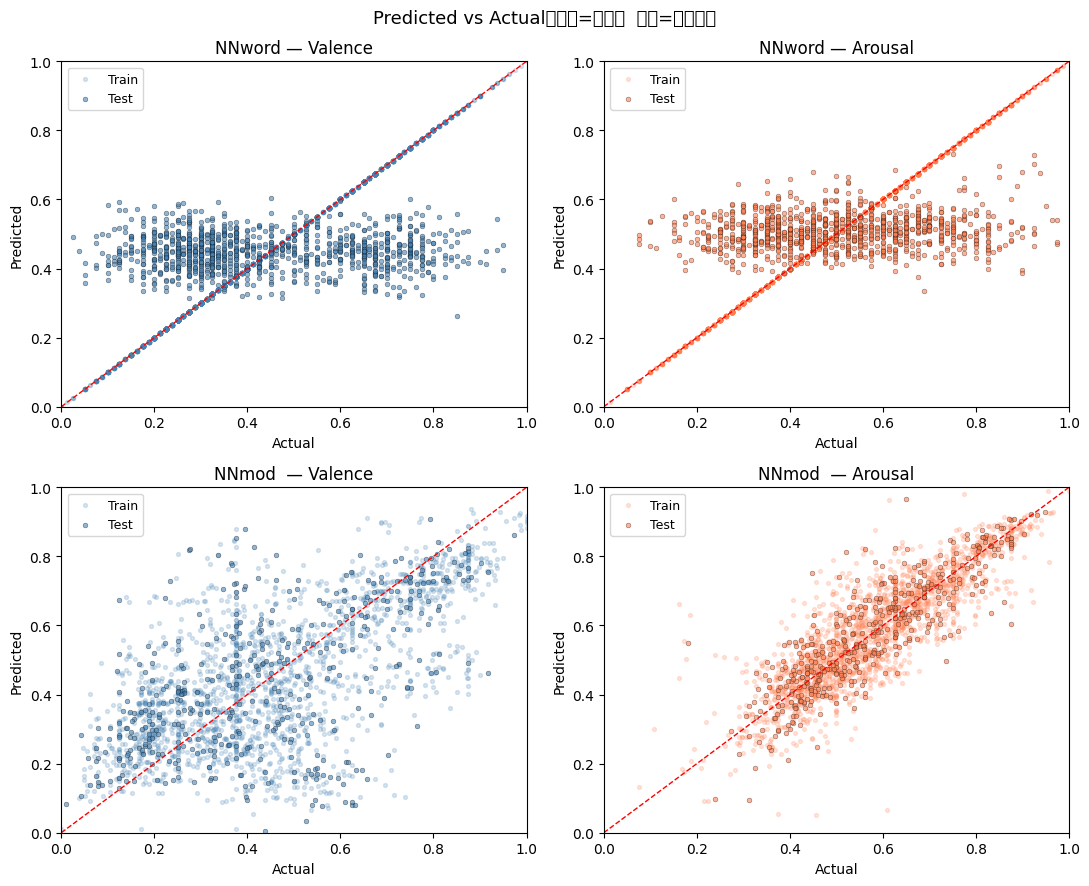

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
fig.suptitle('Predicted vs Actual（淺色=訓練集  深色=測試集）', fontsize=13)

configs = [
    (axes[0,0], pv_trw, gv_trw, pv_tew, gv_tew, 'NNword — Valence', 'steelblue'),
    (axes[0,1], pa_trw, ga_trw, pa_tew, ga_tew, 'NNword — Arousal', 'coral'),
    (axes[1,0], pv_trm, gv_trm, pv_tem, gv_tem, 'NNmod  — Valence', 'steelblue'),
    (axes[1,1], pa_trm, ga_trm, pa_tem, ga_tem, 'NNmod  — Arousal', 'coral'),
]
for ax, ptr, gtr, pte, gte, title, color in configs:
    ax.scatter(gtr, ptr, alpha=0.2, s=8,  color=color, label='Train')
    ax.scatter(gte, pte, alpha=0.6, s=12, color=color,
               edgecolors='black', linewidths=0.3, label='Test')
    ax.plot([0,1],[0,1],'r--', linewidth=1)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(title); ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 10. 互動預測

In [ ]:
def va_label(v, a):
    pol = '正向' if v>=0.625 else ('負向' if v<=0.375 else '中性')
    act = '高喚起' if a>=0.625 else ('低喚起' if a<=0.375 else '中喚起')
    return f'{pol}/{act}'

# 單詞預測
for w in ['開心','難過','憤怒','平靜']:
    v, a, src = predict_word_va(w)
    print(f'「{w}」V={v:.4f} A={a:.4f} → {va_label(v,a)}  {src}')

print()

# 片語預測
for mod, word in [('非常','開心'),('沒有','希望'),('極為','不安'),('相當','平靜')]:
    predict_phrase_va(mod, word, verbose=True)

「開心」V=0.7750 A=0.7000 → 正向/高喚起  (訓練集已知)
「難過」V=0.2500 A=0.5750 → 負向/中喚起  (訓練集已知)
「憤怒」V=0.2000 A=0.7000 → 負向/高喚起  (訓練集已知)
「平靜」V=0.6750 A=0.1750 → 正向/低喚起  (訓練集已知)

「非常開心」核心詞VA=(0.775,0.700) C(mod)=0.574 → V=0.8113 A=0.8419
「沒有希望」核心詞VA=(0.750,0.525) C(mod)=0.279 → V=0.6072 A=0.4934
「極為不安」核心詞VA=(0.350,0.550) C(mod)=0.421 → V=0.2981 A=0.7250
「相當平靜」核心詞VA=(0.675,0.175) C(mod)=0.546 → V=0.7047 A=0.2656


## 11. 多修飾詞遞迴預測

In [ ]:
def predict_multi_mod_va(modifiers, core_word):
    phrase_str = ''.join(modifiers) + core_word
    print(f'\n多修飾詞片語：「{phrase_str}」')
    cur_v, cur_a, src = predict_word_va(core_word)
    cur_label = core_word
    for mod in reversed(modifiers):
        model_mod.eval()
        with torch.no_grad():
            pred_v, pred_a, c_mod = model_mod(
                torch.tensor([[cur_v]], dtype=torch.float32),
                torch.tensor([[cur_a]], dtype=torch.float32),
                torch.tensor(get_vec(mod), dtype=torch.float32).unsqueeze(0)
            )
            new_v, new_a, cm = pred_v.item(), pred_a.item(), c_mod.item()
        print(f'  +「{mod}」→ V:{cur_v:.4f}→{new_v:.4f}  A:{cur_a:.4f}→{new_a:.4f}  [C={cm:.3f}]')
        cur_v, cur_a = new_v, new_a
        cur_label = mod + cur_label
    print(f'  最終 → V={cur_v:.4f}  A={cur_a:.4f}  {va_label(cur_v, cur_a)}')
    return cur_v, cur_a

predict_multi_mod_va(['應該','沒有','非常'], '開心')
predict_multi_mod_va(['完全','不'],          '滿意')
predict_multi_mod_va(['可能','更加'],        '不安')


多修飾詞片語：「應該沒有非常開心」
  +「非常」→ V:0.7750→0.8113  A:0.7000→0.8419  [C=0.574]
  +「沒有」→ V:0.8113→0.6890  A:0.8419→0.8244  [C=0.279]
  +「應該」→ V:0.6890→0.6661  A:0.8244→0.7879  [C=0.465]
  最終 → V=0.6661  A=0.7879  正向/高喚起

多修飾詞片語：「完全不滿意」
  +「不」→ V:0.4370→0.2666  A:0.5471→0.4753  [C=0.247]
  +「完全」→ V:0.2666→0.2440  A:0.4753→0.6057  [C=0.460]
  最終 → V=0.2440  A=0.6057  負向/中喚起

多修飾詞片語：「可能更加不安」
  +「更加」→ V:0.3500→0.3534  A:0.5500→0.6886  [C=0.505]
  +「可能」→ V:0.3534→0.3298  A:0.6886→0.6374  [C=0.465]
  最終 → V=0.3298  A=0.6374  負向/高喚起


(0.32978761196136475, 0.6374223828315735)